<a href="https://colab.research.google.com/github/BootsiesMom/ADS-508-team-project/blob/main/Copy_of_Assignment_3_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving modcloth_final_data.json to modcloth_final_data (2).json


In [ ]:
import pandas as pd

df = pd.read_json("modcloth_final_data.json", lines=True)
df.head()

,item_id,waist,size,quality,cup size,hips,bra size,category,bust,height,user_name,length,fit,user_id,shoe size,shoe width,review_summary,review_text
0,123373,29.0,7,5.0,d,38.0,34.0,new,36,5ft 6in,Emily,just right,small,991571,NaN,NaN,NaN,NaN
1,123373,31.0,13,3.0,b,30.0,36.0,new,NaN,5ft 2in,sydneybraden2001,just right,small,587883,NaN,NaN,NaN,NaN
2,123373,30.0,7,2.0,b,NaN,32.0,new,NaN,5ft 7in,Ugggh,slightly long,small,395665,9.0,NaN,NaN,NaN
3,123373,NaN,21,5.0,dd/e,NaN,NaN,new,NaN,NaN,alexmeyer626,just right,fit,875643,NaN,NaN,NaN,NaN
4,123373,NaN,18,5.0,b,NaN,36.0,new,NaN,5ft 2in,dberrones1,slightly long,small,944840,NaN,NaN,NaN,NaN


In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82790 entries, 0 to 82789
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   item_id         82790 non-null  int64  
 1   waist           2882 non-null   float64
 2   size            82790 non-null  int64  
 3   quality         82722 non-null  float64
 4   cup size        76535 non-null  object 
 5   hips            56064 non-null  float64
 6   bra size        76772 non-null  float64
 7   category        82790 non-null  object 
 8   bust            11854 non-null  object 
 9   height          81683 non-null  object 
 10  user_name       82790 non-null  object 
 11  length          82755 non-null  object 
 12  fit             82790 non-null  object 
 13  user_id         82790 non-null  int64  
 14  shoe size       27915 non-null  float64
 15  shoe width      18607 non-null  object 
 16  review_summary  76065 non-null  object 
 17  review_text     76065 non-null 

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
waist,79908
bust,70936
shoe width,64183
shoe size,54875
hips,26726
review_summary,6725
review_text,6725
cup size,6255
bra size,6018
height,1107


In [ ]:
#preview counts

df['fit'].value_counts()
df['length'].value_counts()
df['category'].value_counts()

,count
category,
new,21488
tops,20364
dresses,18650
bottoms,15266
outerwear,4223
sale,2524
wedding,275


In [ ]:
#drop rows w missing target variables

df = df.dropna(subset=['fit'])

**Pre-processing data**

In [ ]:
#create labels from quality column

labels = df['quality']

In [ ]:
#convert variables to numeric

numeric_vars = ['waist', 'size', 'hips', 'bra size', 'shoe size']
numeric_df = df[numeric_vars].apply(pd.to_numeric, errors='coerce')

In [ ]:
#convert height to inches

def convert_height(val):
    if isinstance(val, str) and 'ft' in val and 'in' in val:
        try:
            parts = val.split('ft')
            feet = int(parts[0])
            inches = int(parts[1].replace('in', '').strip())
            return feet * 12 + inches
        except:
            return None
    return None

numeric_df['height'] = df['height'].apply(convert_height)

In [ ]:
#Clean ‘bust’ column

def convert_bust(val):
    try:
        return int(val)
    except:
        return None

numeric_df['bust'] = df['bust'].apply(convert_bust)

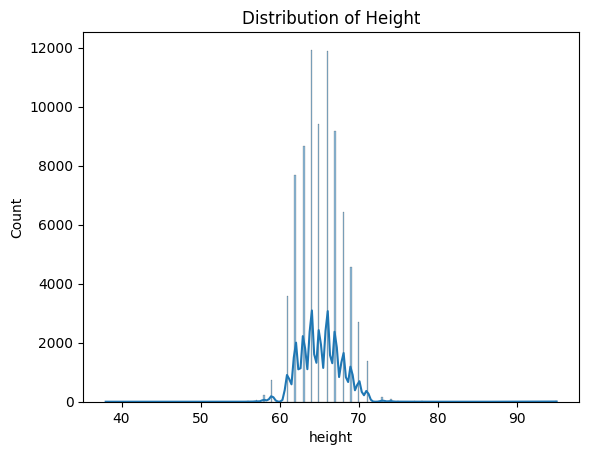

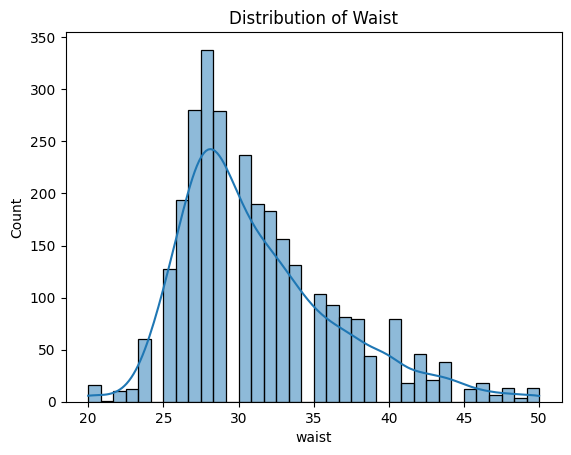

In [ ]:
#check distributions
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(numeric_df['height'].dropna(), kde=True)
plt.title("Distribution of Height")
plt.show()

sns.histplot(numeric_df['waist'].dropna(), kde=True)
plt.title("Distribution of Waist")
plt.show()

In [ ]:
#create cat df
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['cup size', 'length', 'category']
cat_data = df[categorical_cols].dropna()

# Onehot encode
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_encoded = encoder.fit_transform(cat_data)

#convert to df
cat_feat = pd.DataFrame(cat_encoded, columns=encoder.get_feature_names_out(categorical_cols))
cat_feat.index = cat_data.index

**Train Balanced and Unbalanced Perceptron Models**

In [ ]:
#keep rows with non-null 'quality'
df_quality = df[df['quality'].notnull()]

cat_data = df_quality[categorical_cols].dropna()

#oneHotEncode
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
cat_encoded = encoder.fit_transform(cat_data)
cat_feat = pd.DataFrame(cat_encoded, columns=encoder.get_feature_names_out(categorical_cols))
cat_feat.index = cat_data.index

labels = df_quality.loc[cat_feat.index, 'quality']

In [ ]:
#train/test split:

X_train, X_test, y_train, y_test = train_test_split(cat_feat, labels, test_size=0.5, random_state=42)

Unbalanced Classification Report:
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00       612
         2.0       0.11      0.02      0.03      2384
         3.0       0.24      0.54      0.33      9051
         4.0       0.33      0.43      0.37     12737
         5.0       0.35      0.02      0.04     13455

    accuracy                           0.28     38239
   macro avg       0.21      0.20      0.16     38239
weighted avg       0.30      0.28      0.22     38239

Balanced Classification Report:
              precision    recall  f1-score   support

         1.0       0.03      0.14      0.04       612
         2.0       0.12      0.05      0.07      2384
         3.0       0.30      0.06      0.11      9051
         4.0       0.34      0.41      0.37     12737
         5.0       0.37      0.46      0.41     13455

    accuracy                           0.32     38239
   macro avg       0.23      0.22      0.20     38239
weighted av

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


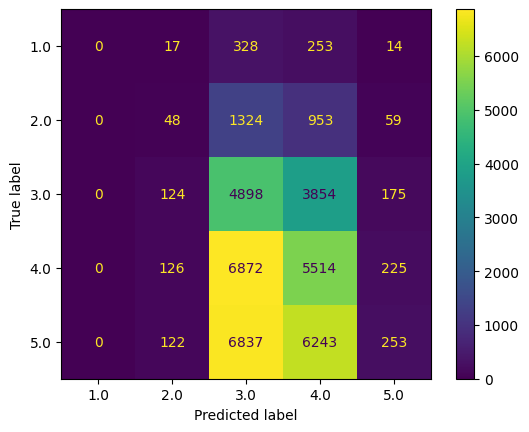

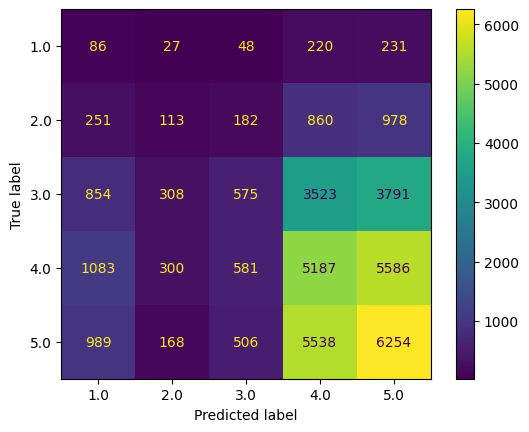

In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn import metrics


#unbalanced model
unbalanced_model = make_pipeline(Perceptron())
unbalanced_model.fit(X_train, y_train)
y_pred_unbalanced = unbalanced_model.predict(X_test)

#balanced model
balanced_model = make_pipeline(Perceptron(class_weight='balanced'))
balanced_model.fit(X_train, y_train)
y_pred_balanced = balanced_model.predict(X_test)

#evaluate unbalanced
print("Unbalanced Classification Report:")
print(metrics.classification_report(y_test, y_pred_unbalanced))
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred_unbalanced)

#evaluate balanced
print("Balanced Classification Report:")
print(metrics.classification_report(y_test, y_pred_balanced))
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred_balanced)

**Work on Numeric Features**

In [ ]:
#cleaning numeric columns first

import numpy as np
import re

def clean_numeric(val):
    try:
        if isinstance(val, (int, float)):
            return val
        if isinstance(val, str):
            val = val.strip().lower()

            #convert ranges
            if '-' in val:
                nums = [float(x) for x in val.split('-') if x.strip().replace('.', '', 1).isdigit()]
                if len(nums) == 2:
                    return np.mean(nums)

            #remove trailing letters
            match = re.match(r'^(\d+(?:\.\d+)?)', val)
            if match:
                return float(match.group(1))

            #if purely numeric
            if val.replace('.', '', 1).isdigit():
                return float(val)

        return np.nan
    except:
        return np.nan

In [ ]:
numeric_cols = ['waist', 'size', 'hips', 'bra size', 'shoe size', 'height', 'bust']

for col in numeric_cols:
    df[col] = df[col].apply(clean_numeric)

In [ ]:
numeric_data = df[numeric_cols]
imputer = SimpleImputer(strategy='mean')
numeric_data_imputed = pd.DataFrame(imputer.fit_transform(numeric_data), columns=numeric_cols)

In [ ]:
#verifying conversion worked
numeric_data_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82790 entries, 0 to 82789
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   waist      82790 non-null  float64
 1   size       82790 non-null  float64
 2   hips       82790 non-null  float64
 3   bra size   82790 non-null  float64
 4   shoe size  82790 non-null  float64
 5   height     82790 non-null  float64
 6   bust       82790 non-null  float64
dtypes: float64(7)
memory usage: 4.4 MB


**Extract and encode categorical features**

In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['cup size', 'length', 'category']
cat_data = df[cat_cols].fillna('missing')

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_feat = pd.DataFrame(
    encoder.fit_transform(cat_data),
    columns=encoder.get_feature_names_out(cat_cols)
)

In [ ]:
#remove rows where labels are missing
valid_indices = labels.dropna().index

#filter
cat_feat = cat_feat.loc[valid_indices]
labels = labels.loc[valid_indices]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    cat_feat, labels, test_size=0.5, random_state=42
)

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Perceptron

balanced_model = make_pipeline(Perceptron(class_weight='balanced', random_state=42))
unbalanced_model = make_pipeline(Perceptron(random_state=42))

balanced_model.fit(X_train, y_train)
unbalanced_model.fit(X_train, y_train)

Pipeline(steps=[('perceptron', Perceptron(random_state=42))])

Balanced Model Report
              precision    recall  f1-score   support

         1.0       0.02      0.20      0.04       612
         2.0       0.07      0.05      0.06      2384
         3.0       0.26      0.14      0.18      9051
         4.0       0.36      0.10      0.16     12737
         5.0       0.38      0.63      0.47     13455

    accuracy                           0.29     38239
   macro avg       0.22      0.22      0.18     38239
weighted avg       0.32      0.29      0.27     38239

Unbalanced Model Report
              precision    recall  f1-score   support

         1.0       0.03      0.01      0.01       612
         2.0       0.13      0.01      0.01      2384
         3.0       0.35      0.03      0.06      9051
         4.0       0.33      0.97      0.50     12737
         5.0       0.00      0.00      0.00     13455

    accuracy                           0.33     38239
   macro avg       0.17      0.20      0.12     38239
weighted avg       0.20      0.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


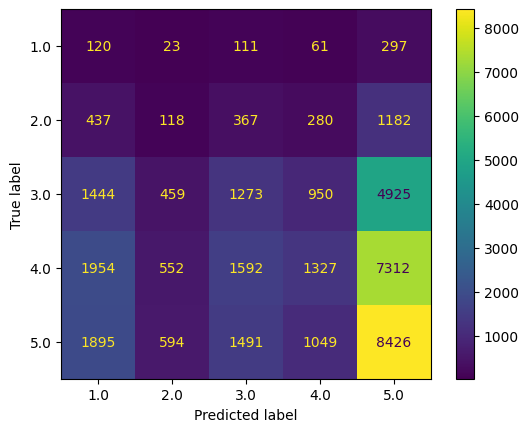

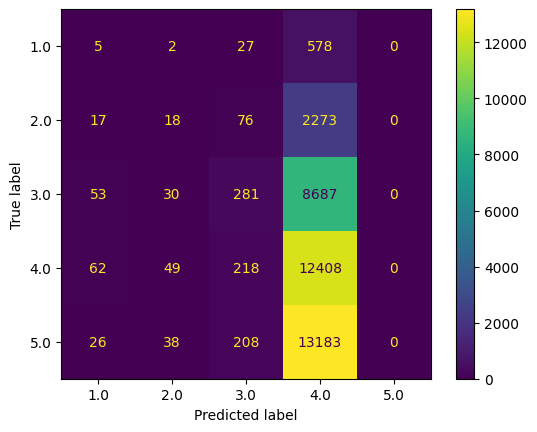

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

#balanced model
print("Balanced Model Report")
print(classification_report(y_test, balanced_model.predict(X_test)))

ConfusionMatrixDisplay.from_estimator(balanced_model, X_test, y_test)

#unbalanced model
print("Unbalanced Model Report")
print(classification_report(y_test, unbalanced_model.predict(X_test)))

ConfusionMatrixDisplay.from_estimator(unbalanced_model, X_test, y_test)

**combine categoric and numerical feats**

In [ ]:
from sklearn.compose import ColumnTransformer

full_features = pd.concat([cat_feat.reset_index(drop=True),
                           numeric_data_imputed.loc[cat_feat.index].reset_index(drop=True)], axis=1)

**Create Pipelines**

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Perceptron
from sklearn.pipeline import make_pipeline
import numpy as np
import pandas as pd

#create pipelines
pipeline_imputer = make_pipeline(SimpleImputer(), Perceptron(class_weight='balanced', random_state=42))
pipeline_normalizer = make_pipeline(Normalizer(), Perceptron(class_weight='balanced', random_state=42))
pipeline_scaler = make_pipeline(StandardScaler(), Perceptron(class_weight='balanced', random_state=42))

#list of pipelines and labels
pipelines = {
    'Imputer': pipeline_imputer,
    'Normalizer': pipeline_normalizer,
    'Scaler': pipeline_scaler
}

#align indices before training
labels_aligned = labels.loc[labels.index.intersection(full_features.index)]
features_aligned = full_features.loc[labels_aligned.index]

#run and collect results
results = []
for label, pipe in pipelines.items():
    scores = cross_val_score(pipe, features_aligned, labels_aligned, cv=5, scoring='accuracy')
    results.append({
        'Pipeline': label,
        'Min Accuracy': np.min(scores),
        'Max Accuracy': np.max(scores),
        'Mean Accuracy': np.mean(scores)
    })
results_df = pd.DataFrame(results)
results_df

,Pipeline,Min Accuracy,Max Accuracy,Mean Accuracy
0,Imputer,0.218841,0.326562,0.268299
1,Normalizer,0.048765,0.297049,0.204445
2,Scaler,0.170147,0.275037,0.231481


**Text Data from Reviews**

In [ ]:
cat_feat_backup = cat_feat.copy()
labels_backup = labels.copy()

In [ ]:
import pandas as pd

modcloth = pd.read_json("modcloth_final_data.json", lines=True)

In [ ]:
# Recreate labels to match the reloaded modcloth DataFrame
labels = modcloth['fit']


corpus = modcloth['review_text'].dropna()
labels_text = labels.loc[corpus.index]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_text = vectorizer.fit_transform(corpus)

In [ ]:
y_text = labels_text

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_text, y_text, test_size=0.5, random_state=42)

In [ ]:
#feature selection with chi-squared
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=1000)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

clf = Perceptron()
clf.fit(X_train_selected, y_train)
y_pred = clf.predict(X_test_selected)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7332053742802304


k=10, Accuracy=0.6745
k=25, Accuracy=0.7072
k=50, Accuracy=0.7096
k=100, Accuracy=0.7180
k=250, Accuracy=0.7344
k=500, Accuracy=0.7243
k=1000, Accuracy=0.7332
k=10000, Accuracy=0.7313


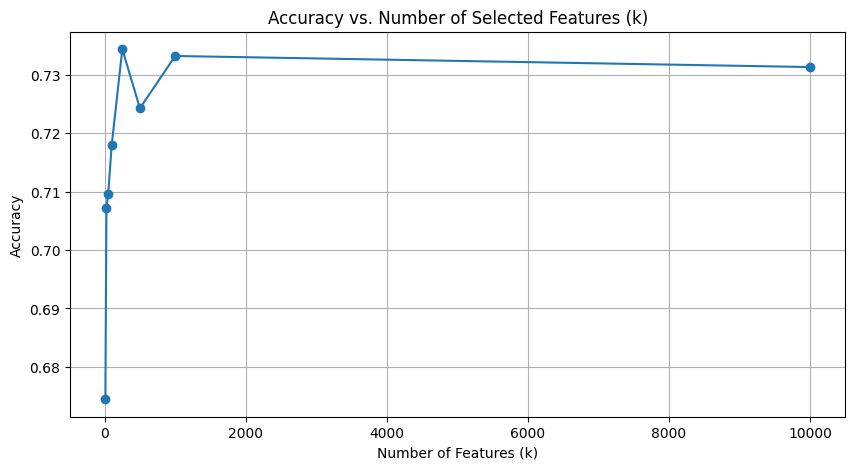

In [ ]:
#loop over k-values and ploit

import matplotlib.pyplot as plt

k_values = [10, 25, 50, 100, 250, 500, 1000, 10000]
accuracies = []

for k in k_values:
    selector = SelectKBest(score_func=chi2, k=k)
    X_train_k = selector.fit_transform(X_train, y_train)
    X_test_k = selector.transform(X_test)

    clf = Perceptron()
    clf.fit(X_train_k, y_train)
    y_pred_k = clf.predict(X_test_k)

    acc = accuracy_score(y_test, y_pred_k)
    accuracies.append(acc)

    print(f"k={k}, Accuracy={acc:.4f}")

#plot results
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o')
plt.title("Accuracy vs. Number of Selected Features (k)")
plt.xlabel("Number of Features (k)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [ ]:
selector = SelectKBest(score_func=chi2, k=1000)
X_train_selected = selector.fit_transform(X_train, y_train)

#top 10 features
import numpy as np

top_indices = np.argsort(selector.scores_)[-10:][::-1]
feature_names = vectorizer.get_feature_names_out()
top_features = [feature_names[i] for i in top_indices]

print("Top 10 features:")
for i, feat in enumerate(top_features, 1):
    print(f"{i}. {feat}")

Top 10 features:
1. midrib
2. midrange
3. midmay
4. singular
5. midlower
6. sinon
7. sip
8. midkneecap
9. sirs
10. bishop
